<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/LOAD_IRIS_APRENDENDO_SKLEARN_E_SEUS_USOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data      # features
y = iris.target    # rótulos

In [3]:
import pandas as pd

df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [6]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_logreg = logreg_pipeline.predict(X_test)
acc_logreg = accuracy_score(y_test, y_pred_logreg)

print("Acurácia - Logistic Regression:", acc_logreg)
print("\nRelatório de classificação (Logistic Regression):")
print(classification_report(y_test, y_pred_logreg, target_names=iris.target_names))

Acurácia - Logistic Regression: 1.0

Relatório de classificação (Logistic Regression):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("Acurácia - KNN:", acc_knn)
print("\nRelatório de classificação (KNN):")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

Acurácia - KNN: 1.0

Relatório de classificação (KNN):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



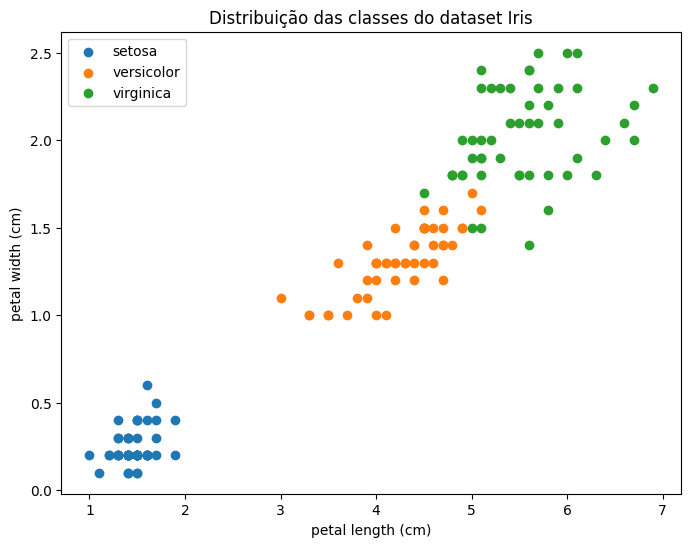

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris

# Carregar dados
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Escolher duas features: pétala comprimento x pétala largura
x_index, y_index = 2, 3  # (petal length, petal width)

plt.figure(figsize=(8,6))
for i, target_name in enumerate(target_names):
    plt.scatter(X[y == i, x_index], X[y == i, y_index], label=target_name)

plt.xlabel(feature_names[x_index])
plt.ylabel(feature_names[y_index])
plt.legend()
plt.title("Distribuição das classes do dataset Iris")
plt.show()